In [4]:
# 모듈성(modularity) : 시스템을 독립시켜 재사용 가능하게 만듦.
# 데이터 샘플을 처리하는 코드는 지저분하고 유지보수가 어렵다.
# 가독성과 모듈성을 위해 데이터셋 코드를 학습 코드로부터 분리시킨다.

# Dataset은 샘플과 정답을 저장
# sample(샘플) : 모델을 학습시키기 위한 입력 데이터
# label(정답) : 그 입력 데이터에 해당하는 정답 값

# DataLoader는 Dataset을 iterable로 감싼다.
# Pytorch는 도메인 특화 라이브러리를 제공
# 데이터셋은 개별 데이터를 특정하는 함수가 구현
# 이러한 데이터셋은 모델(prototype)을 만들어보고 성능을 측정(benchmark)하는 데 사용 가능

In [5]:
# Fashion-MNIST : 60000개의 모델 학습(모델 훈련) 데이터와 10000개의 모델 테스트(학습된 모델 시험) 데이터로 구성
# 샘플 : 흑백(grayscale)의 28x28 이미지
# 정답 : 이미지에 대한 올바른 값
# 샘플은 수만 개이지만 그것을 10개의 분류로 나누어 정답을 표현

# Fashion-MNIST 데이터셋 불러오기
# root : 학습/테스트 데이터가 저장되는 경로
# train : 학습인지 테스트인지 여부를 지정
# download : True이면 root에 데이터가 없을 때 인터넷에서 다운로드
# feature(특징) : 샘플을 구성하는 특정 요소들 (이미지라면 픽셀 값들)
# transform 과 target_transform : 특징(feature)과 정답(label) 변형(transform)을 지정
# transform하기 전의 raw데이터는 모델이 학습하기 어려워하므로 transform을 지정함으로써 모델이 학습하기 편함.
import torch
from torch.utils.data import Dataset
from torchvision import datasets
from torchvision.transforms import ToTensor
import matplotlib.pyplot as plt 

training_data = datasets.FashionMNIST(
  root="data",
  train=True,
  download=True,
  transform=ToTensor()
)

test_data = datasets.FashionMNIST(
  root="data",
  train=False,
  download=True,
  transform=ToTensor()
)

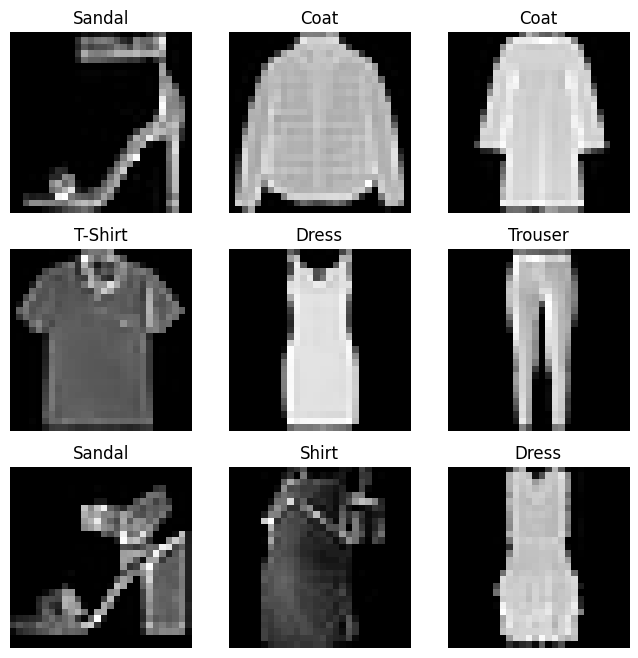

In [ ]:
# label의 정답을 우리가 알 수 있게 보여주는 객체
labels_map = {
  0: "T-Shirt",
  1: "Trouser",
  2: "Pullover",
  3: "Dress",
  4: "Coat",
  5: "Sandal",
  6: "Shirt",
  7: "Sneaker",
  8: "Bag",
  9: "Ankle Boot",
}
figure = plt.figure(figsize=(8, 8))
cols, rows = 3, 3
for i in range(1, cols * rows + 1):
  sample_idx = torch.randint(len(training_data), size=(1,)).item() # 샘플의 idx를 가져옴
  img, label = training_data[sample_idx] # 학습 모델의 이미지와 정답을 꺼내기
  figure.add_subplot(rows, cols, i)
  plt.title(labels_map[label])
  plt.axis("off")
  # squeeze() : 크기가 1인 차원을 자동으로 제거
  # 예: (1, 28, 28) → (28, 28)
  # 불필요한 차원을 제거해 이미지가 보이게 하기 (컴퓨터는 2차원만 볼 수 있고 학습은 3차원으로 하기 때문)
  plt.imshow(img.squeeze(), cmap="gray")
plt.show()